In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

In [2]:
token = os.getenv("GITHUB_TOKEN")
endpoint = "https://models.github.ai/inference"
model = "openai/gpt-4.1-mini"

In [3]:
llm = ChatOpenAI(
    model=model,
    api_key=token,
    base_url=endpoint
)

In [4]:
from langgraph.types import Command

In [5]:
from langgraph.prebuilt import create_react_agent

In [6]:
def add_number(state):
    result = state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply", update={"sum":result})

In [7]:
state = {"num1":10, "num2":20}

In [8]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

Creating one dummy multiagent

In [15]:
from typing import Annotated,Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [17]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    name:str
    age: int
    DOB: int

In [18]:
def transfer_to_multiplication_expert():
    "Ask multiplicatin agent for a help"
    return

In [19]:
def transfer_to_additon_expert():
    "Ask addition agent for a help"
    return

In [20]:
llm_with_tools = llm.bind_tools([transfer_to_multiplication_expert])

In [21]:
response = llm_with_tools.invoke("hi")

In [22]:
response.content

'Hello! How can I assist you today?'

In [23]:
response.tool_calls

[]

In [24]:
response = llm_with_tools.invoke("what is 2 multiply by 2")

In [25]:
response.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': 'call_L1ApOleD7LP9bPtXOpVnTH3i',
  'type': 'tool_call'}]

In [26]:
from typing_extensions import Literal
from langgraph.graph import MessagesState, StateGraph, START, END

In [ ]:
def additon_expert(state:MessagesState)-> Command[Literal["additional_expert","__end__"]]:
    pass

In [28]:
def multiplication_expert(state:MessagesState)-> Command[Literal["multiplication_expert","__end__"]]:
    pass

In [30]:
graph= StateGraph(MessagesState)

In [31]:
graph.add_node("additon_expert", additon_expert)

In [32]:
graph.add_node("multiplication_expert", multiplication_expert)

In [34]:
graph.add_edge(START,"additon_expert")

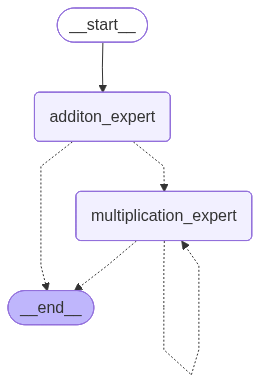

In [35]:
graph.compile()